In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", X_test.shape)
print("Testing labels :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2556s 15us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images : (10000, 32, 32, 3)
Testing labels : (10000, 1)


In [3]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training pixel range:", X_train.min(), "to", X_train.max())

Training pixel range: 0.0 to 1.0


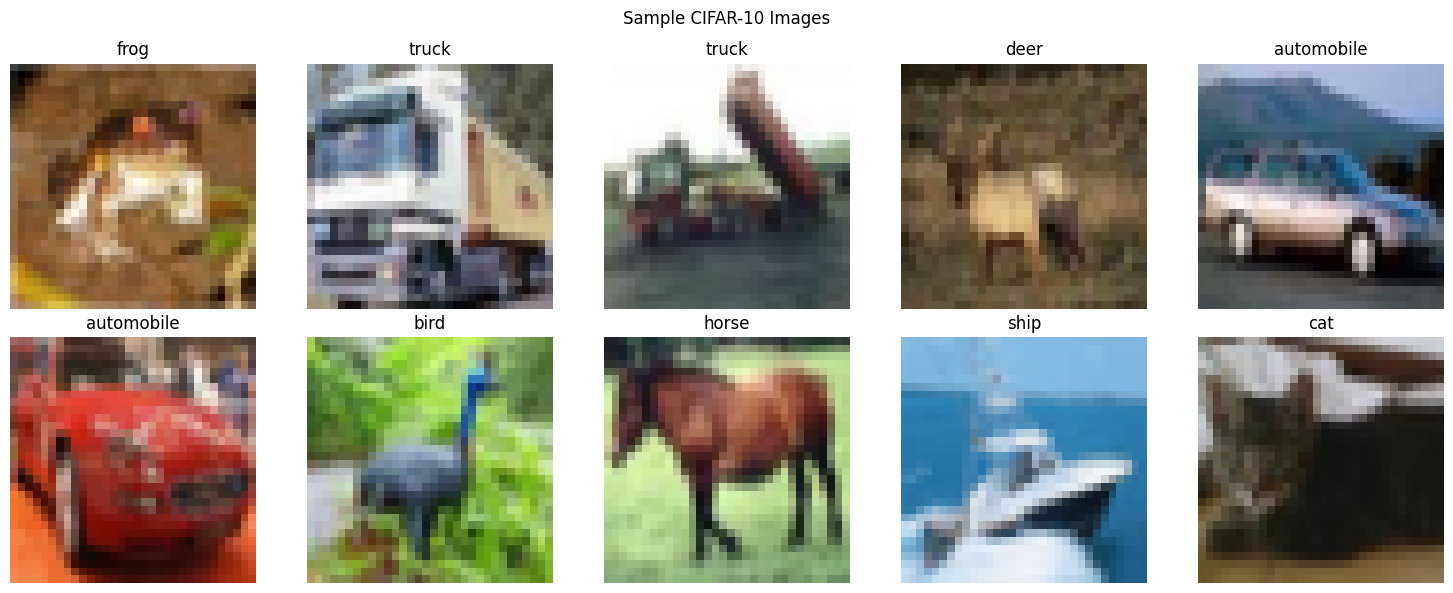

In [5]:
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

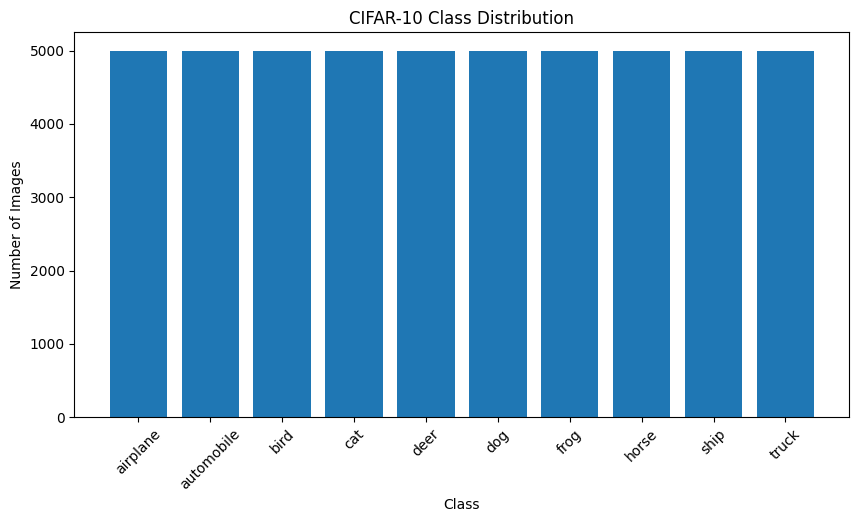

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))

plt.bar(
    [class_names[i] for i in unique],
    counts
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")
plt.xticks(rotation=45)

plt.show()

In [7]:
input_shape = (32, 32, 3)

kernel_sizes = [3, 5, 7]

for k in kernel_sizes:

    conv = layers.Conv2D(
        filters=16,
        kernel_size=(k, k),
        strides=1,
        padding="valid",
        input_shape=input_shape
    )

    output_shape = conv.compute_output_shape((None, 32, 32, 3))

    print(f"Kernel Size: {k}x{k}")
    print("Output Shape:", output_shape)
    print()

Kernel Size: 3x3
Output Shape: (None, 30, 30, 16)

Kernel Size: 5x5
Output Shape: (None, 28, 28, 16)

Kernel Size: 7x7
Output Shape: (None, 26, 26, 16)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
configs = [
    ("Stride 1, Valid", 1, "valid"),
    ("Stride 2, Valid", 2, "valid"),
    ("Stride 1, Same", 1, "same"),
    ("Stride 2, Same", 2, "same")
]

for name, stride, padding in configs:

    conv = layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        strides=stride,
        padding=padding
    )

    output_shape = conv.compute_output_shape(
        (None, 32, 32, 3)
    )

    print(name)
    print("Output Shape:", output_shape)
    print()

Stride 1, Valid
Output Shape: (None, 30, 30, 16)

Stride 2, Valid
Output Shape: (None, 15, 15, 16)

Stride 1, Same
Output Shape: (None, 32, 32, 16)

Stride 2, Same
Output Shape: (None, 16, 16, 16)



In [9]:
feature_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2))
])

feature_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
sample_image = X_test[0:1]

feature_maps = feature_model.predict(sample_image)

print("Feature map shape:", feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Feature map shape: (1, 16, 16, 32)


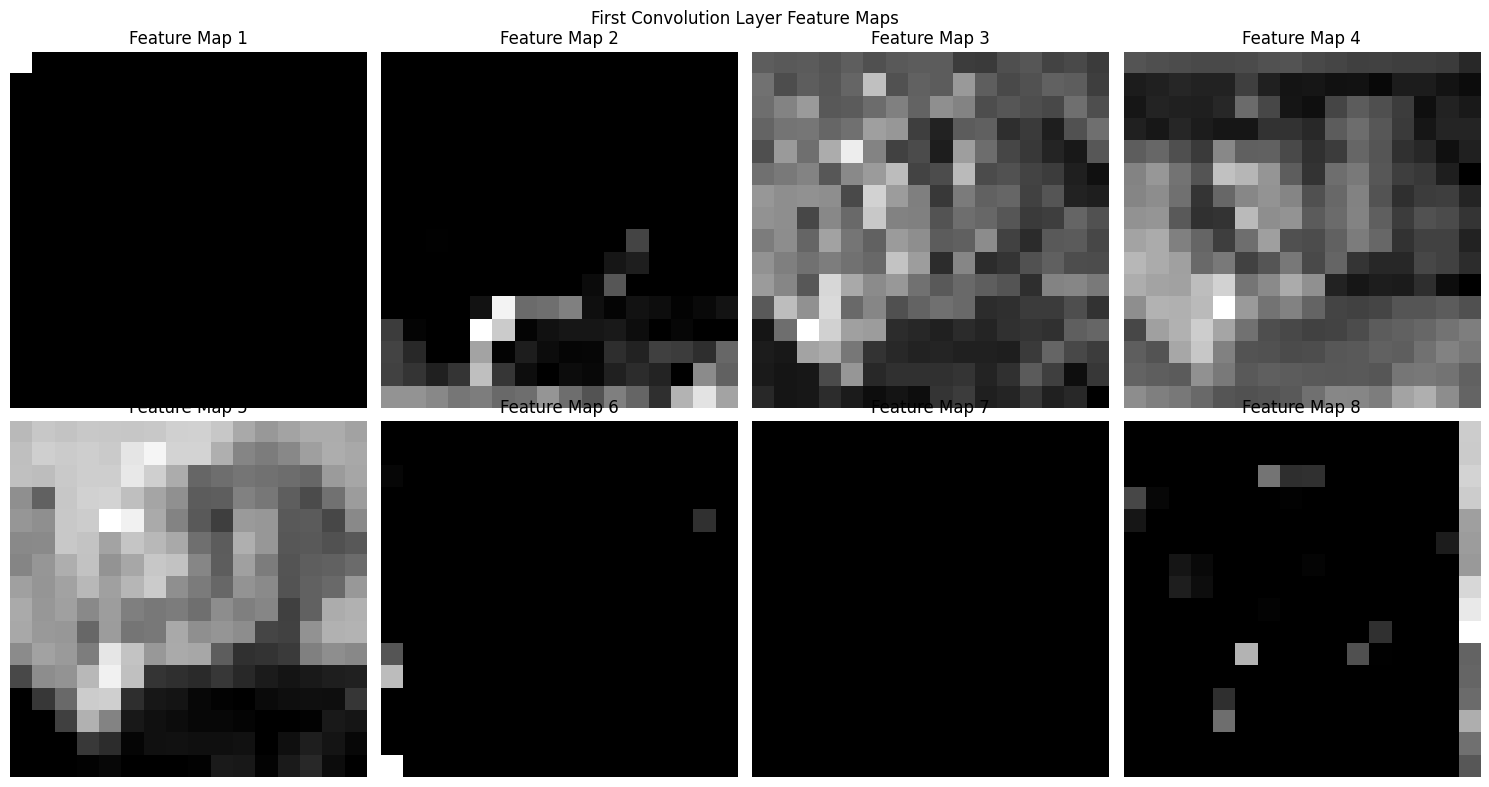

In [11]:
plt.figure(figsize=(15, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(feature_maps[0, :, :, i], cmap="gray")

    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.suptitle("First Convolution Layer Feature Maps")
plt.tight_layout()
plt.show()

In [12]:
sample_feature_map = feature_maps[0, :, :, 0]

sample_feature_map = sample_feature_map.reshape(
    1,
    sample_feature_map.shape[0],
    sample_feature_map.shape[1],
    1
)

max_pool = layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=2
)

avg_pool = layers.AveragePooling2D(
    pool_size=(2, 2),
    strides=2
)

max_output = max_pool(sample_feature_map)
avg_output = avg_pool(sample_feature_map)

print("Original shape :", sample_feature_map.shape)
print("Max Pool shape :", max_output.shape)
print("Avg Pool shape :", avg_output.shape)

Original shape : (1, 16, 16, 1)
Max Pool shape : (1, 8, 8, 1)
Avg Pool shape : (1, 8, 8, 1)


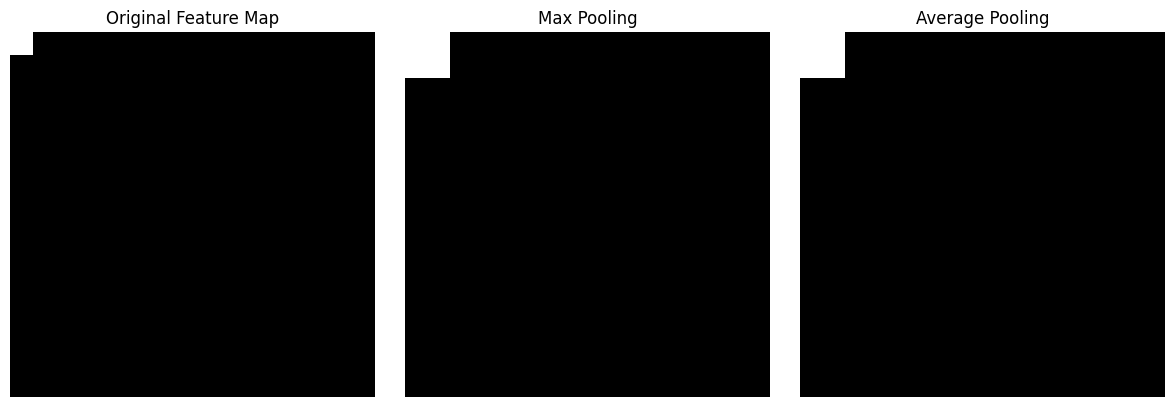

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_feature_map[0, :, :, 0], cmap="gray")
plt.title("Original Feature Map")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(max_output[0, :, :, 0], cmap="gray")
plt.title("Max Pooling")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(avg_output[0, :, :, 0], cmap="gray")
plt.title("Average Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    # First Convolution Block
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second Convolution Block
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Fully Connected Section
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 89s 62ms/step - accuracy: 0.5005 - loss: 1.3875 - val_accuracy: 0.5582 - val_loss: 1.2295
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 138s 59ms/step - accuracy: 0.6388 - loss: 1.0244 - val_accuracy: 0.6596 - val_loss: 0.9620
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.6901 - loss: 0.8832 - val_accuracy: 0.6968 - val_loss: 0.9038
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 143s 60ms/step - accuracy: 0.7251 - loss: 0.7819 - val_accuracy: 0.7090 - val_loss: 0.8665
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.7551 - loss: 0.6945 - val_accuracy: 0.6964 - val_loss: 0.9094
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 141s 59ms/step - accuracy: 0.7846 - loss: 0.6132 - val_accuracy: 0.7146 - val_loss: 0.8766
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.8092 - loss: 0.5432 - val_accuracy: 0.7148 - val_loss: 0.8978
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 143s 60ms/step - accuracy: 0.83

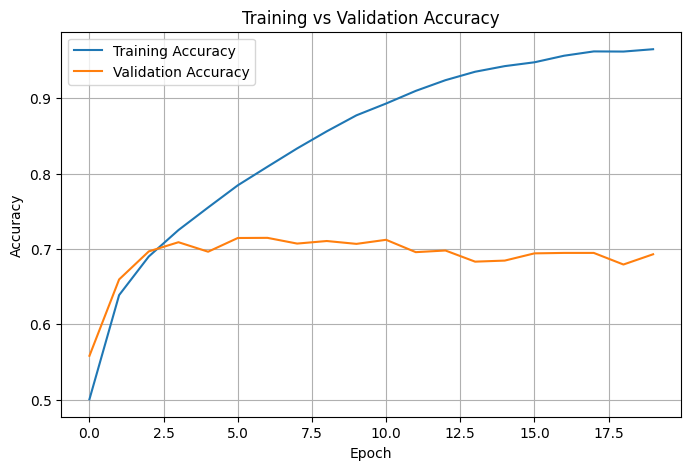

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

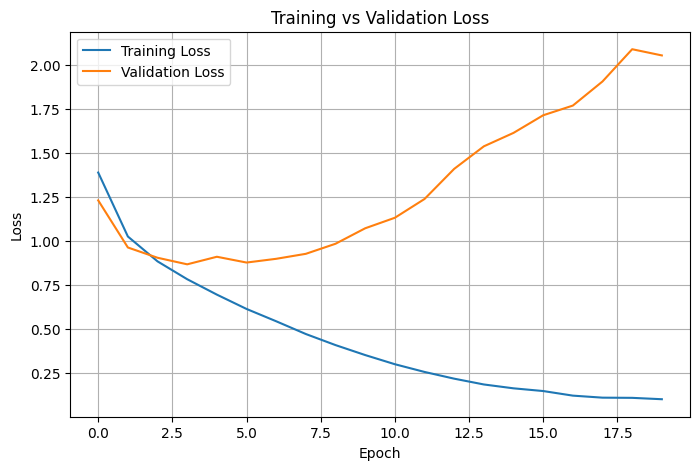

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6765 - loss: 2.1651
Test Loss: 2.165130138397217
Test Accuracy: 0.6765000224113464


In [20]:
y_probability = model.predict(X_test)

y_pred = np.argmax(
    y_probability,
    axis=1
)

y_true = y_test.flatten()

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Predictions generated successfully.


In [21]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.6765
Accuracy (%): 67.65


In [22]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Precision: 0.6832796077639779
Recall   : 0.6765
F1 Score : 0.6781626601200097


In [23]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.69      0.77      0.73      1000
  automobile       0.80      0.79      0.80      1000
        bird       0.57      0.57      0.57      1000
         cat       0.46      0.53      0.49      1000
        deer       0.65      0.58      0.61      1000
         dog       0.56      0.56      0.56      1000
        frog       0.81      0.68      0.74      1000
       horse       0.68      0.77      0.72      1000
        ship       0.83      0.74      0.78      1000
       truck       0.78      0.78      0.78      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



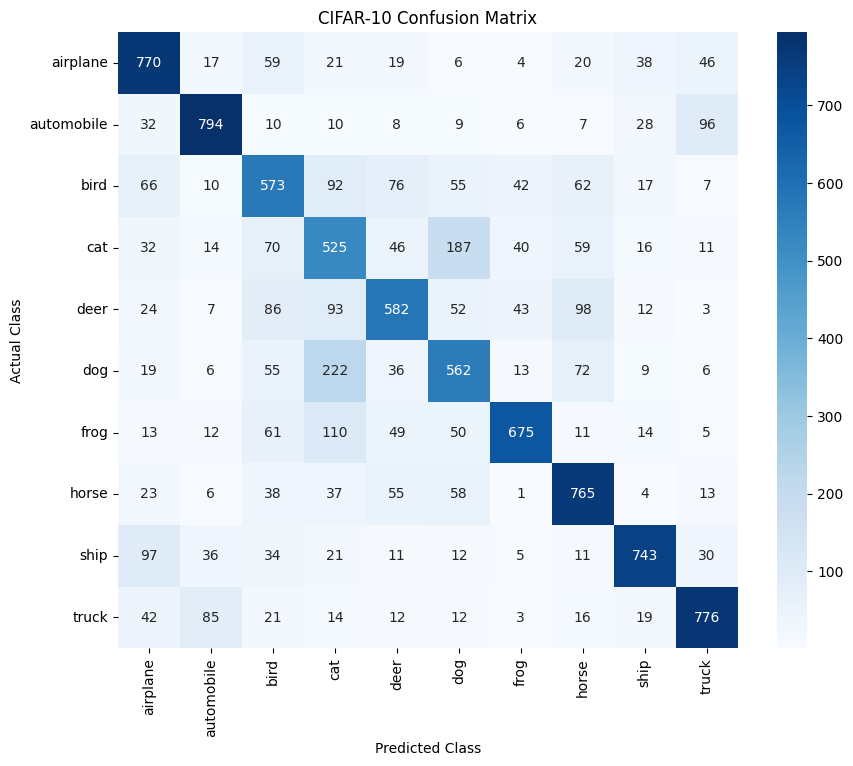

In [24]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

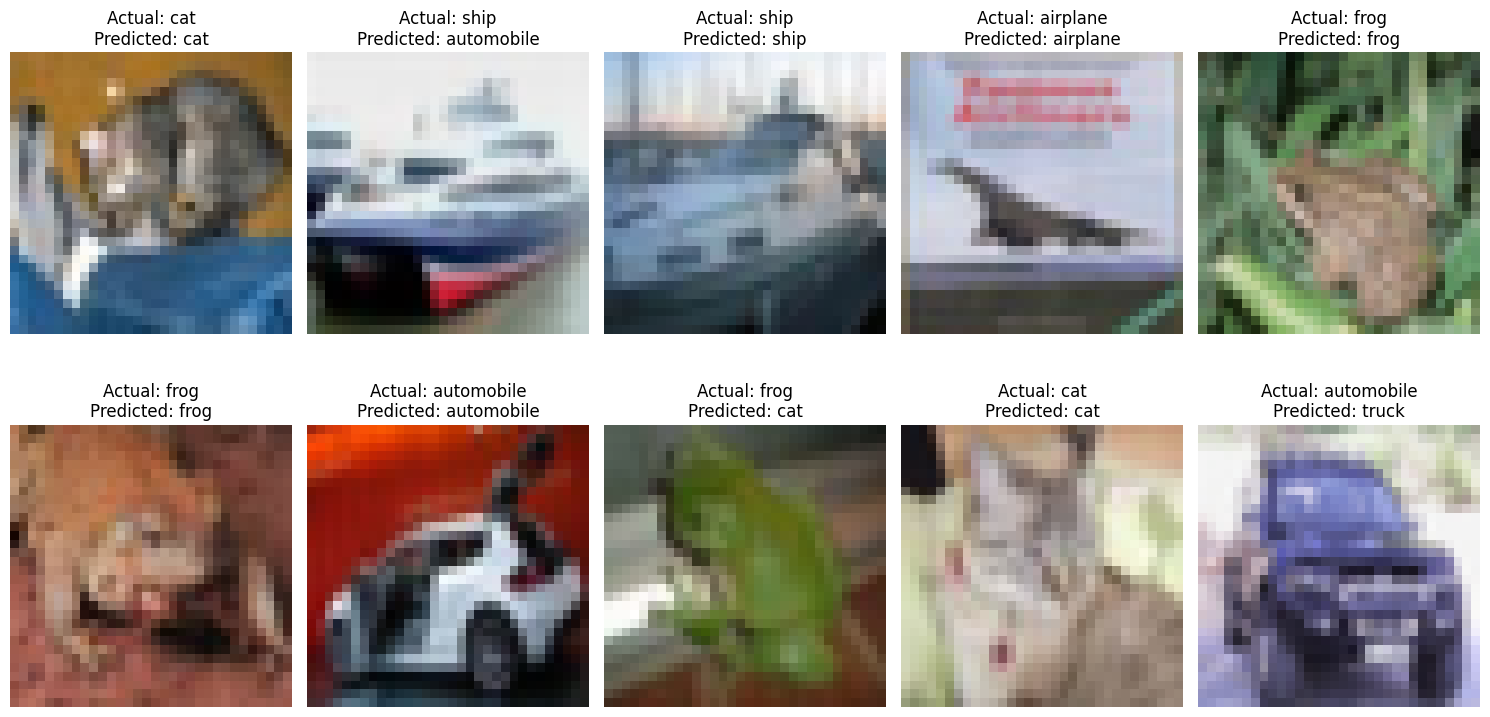

In [25]:
plt.figure(figsize=(15, 8))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
params_first_conv = (
    (3 * 3 * 3) + 1
) * 32

print(
    "First Conv Layer Parameters:",
    params_first_conv
)

First Conv Layer Parameters: 896


In [36]:
avg_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.AveragePooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.AveragePooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

avg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

avg_history = avg_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Extract feature maps from the TRAINED CNN

feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[0].output
)

sample_image = X_test[0:1]

feature_maps = feature_model.predict(sample_image)

print("Feature map shape:", feature_maps.shape)

plt.figure(figsize=(15, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    plt.title(f"Feature Map {i+1}")
    plt.axis("off")

plt.suptitle("Feature Maps from Trained First Convolution Layer")
plt.tight_layout()
plt.show()

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.4678 - loss: 1.4779 - val_accuracy: 0.5518 - val_loss: 1.2309
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 55ms/step - accuracy: 0.5989 - loss: 1.1388 - val_accuracy: 0.6440 - val_loss: 1.0273
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.6512 - loss: 0.9845 - val_accuracy: 0.6642 - val_loss: 0.9605
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.6896 - loss: 0.8828 - val_accuracy: 0.6746 - val_loss: 0.9233
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.7189 - loss: 0.7975 - val_accuracy: 0.6922 - val_loss: 0.8896
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.7445 - loss: 0.7256 - val_accuracy: 0.6894 - val_loss: 0.9250
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 56ms/step - accuracy: 0.7683 - loss: 0.6559 - val_accuracy: 0.7062 - val_loss: 0.8888
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.7921 -

AttributeError: The layer sequential_1 has never been called and thus has no defined input.

In [28]:
avg_loss, avg_accuracy = avg_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Max Pooling Accuracy :", test_accuracy)
print("Average Pooling Accuracy:", avg_accuracy)

Max Pooling Accuracy : 0.6765000224113464
Average Pooling Accuracy: 0.6845999956130981


In [29]:
pooling_results = pd.DataFrame({
    "Pooling Method": [
        "Max Pooling",
        "Average Pooling"
    ],
    "Test Accuracy": [
        test_accuracy,
        avg_accuracy
    ]
})

pooling_results

,Pooling Method,Test Accuracy
0,Max Pooling,0.6765
1,Average Pooling,0.6846


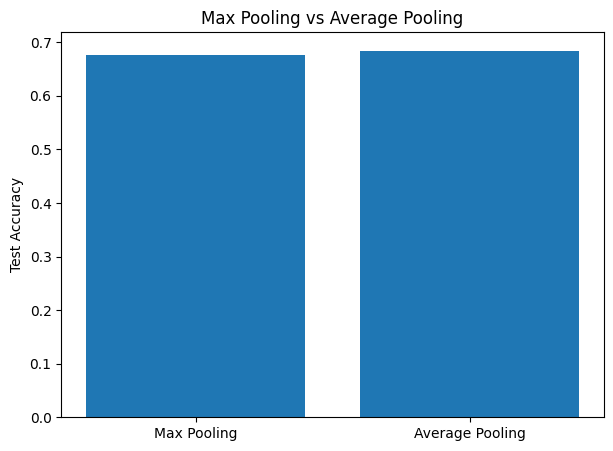

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(
    pooling_results["Pooling Method"],
    pooling_results["Test Accuracy"]
)

plt.ylabel("Test Accuracy")
plt.title("Max Pooling vs Average Pooling")

plt.show()

In [31]:
train_accuracy = history.history["accuracy"][-1]

results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Total Parameters"
    ],
    "Value": [
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        model.count_params()
    ]
})

results

,Metric,Value
0,Training Accuracy,0.965289
1,Testing Accuracy,0.676500
2,Precision,0.683280
3,Recall,0.676500
4,F1 Score,0.678163
5,Total Parameters,545098.000000


In [32]:
print("=" * 50)
print("          CNN EXPERIMENT RESULTS")
print("=" * 50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Total Parameters  : {model.count_params()}")

print("=" * 50)

          CNN EXPERIMENT RESULTS
Training Accuracy : 0.9653
Testing Accuracy  : 0.6765
Precision         : 0.6833
Recall            : 0.6765
F1 Score          : 0.6782
Total Parameters  : 545098


In [33]:
N = 64
F = 5
S = 2
P = 2

output = ((N - F + 2 * P) // S) + 1

print("Output Size:", output, "x", output)

Output Size: 32 x 32


In [34]:
filters = 64
kernel = 3
input_channels = 3

parameters = (
    (kernel * kernel * input_channels) + 1
) * filters

print("Trainable Parameters:", parameters)

Trainable Parameters: 1792


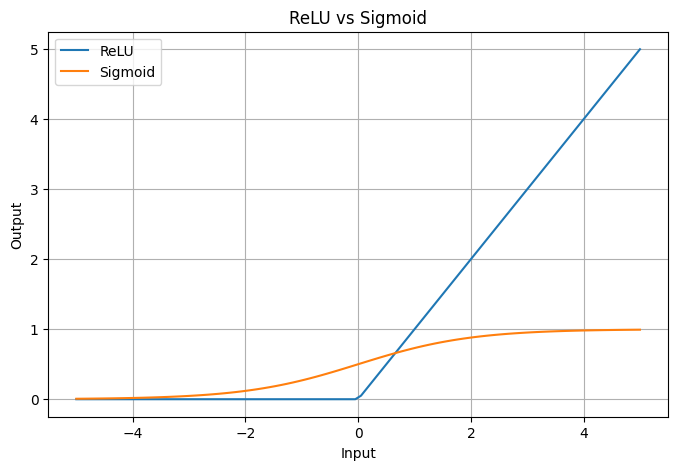

In [35]:
x = np.linspace(-5, 5, 100)

relu = np.maximum(0, x)

sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 5))

plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("ReLU vs Sigmoid")
plt.legend()
plt.grid()

plt.show()